## Simulating a Storm using Operational Model Output Data

**Author:** Alison Gregory  
**Course:** GEOG 5663 Capstone | University of Colorado  
**Industry Partner:** NOAA's Earth Prediction Innovation Center (EPIC)  
**Date:** Summer 2026

---

### About This Notebook;

This notebook pulls **archived HRRR (High-Resolution Rapid Refresh) model data**
directly from NOAA's public AWS bucket using the [Herbie](https://herbie.readthedocs.io/) Python package — no HPC account, no manual downloads, no GRIB2 wrangling required. Anyone can run this notebook top to bottom with just a Python environment and an internet
connection.

**This is not a UFS Short-Range Weather (SRW) App run.** [The Short Range Weather App Tutorial](https://ufs.epic.noaa.gov/srw-tutorial-august102020-derecho/) allows a user to run the model under four configurations (two physics suites and two grid resolutions) while evaluating how well *newly generated* forecasts captured the derecho. That work requires HPC access and remains a distinct limiting factor for engagement with the Unified Forecast System (UFS). 

This notebook is intended to be a supplement to that tutorial so new users unfamiliar with coding and forecasts can begin to understand how operational forecast models work. This notebook uses the *operational HRRR archive* (the real forecasts and analyses that were actually produced on August 10, 2020) to explore the same core questions in an accessible, zero-setup way:

1. What did 10-m wind speed at Cedar Rapids, Iowa actually look like as the derecho passed through?
2. How well did HRRR *forecast* the event ahead of time, versus what the *analysis* (best estimate of reality) showed after the fact?
3. How does the model's wind field compare to the damage-survey estimate of up to 140 mph gusts and the SPC's severe weather outlooks that day?
### About the HRRR:
It is important to note that the HRRR runs on WRF-ARW, which is a single-core model, using the ARW dynamical core. Not only does the HRRR model use different dynamical cores but it also uses different resolutions and physics.  
### About the Case Study: 

On the morning of August 10, 2020, a cluster of thunderstorms over South Dakota organized into a derecho that tracked east across Iowa, Illinois, Wisconsin, and Indiana. It struck the Cedar Rapids, Iowa metro area around **12:30 PM CDT (17:30 UTC)**, producing sustained winds
estimated at 100–130 mph and gusts estimated as high as 140 mph in southwest Cedar Rapids — the most severe damage of the entire event. It
remains the costliest thunderstorm in U.S. history and was notably under-forecast in real time, which is what makes it useful for this kind
of model evaluation.

> **Note for viewers:** You do not need to run anything outside of this notebook. All outputs are pre-executed and embedded.

## 1. Notebook Setup

This project uses herbie-data to find and download HRRR files from NOAA's public AWS archive. The remaining imported packages will be used for standard python operation and visualization.

In [1]:
%pip install -q herbie-data xarray matplotlib cartopy pandas numpy
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from herbie import Herbie

plt.rcParams["figure.dpi"] = 110 # Improve resolution for viewing maps

### Potential relevant variables from GRIB2 File

TMP - temperature (2m above ground)
DPT - dewpoint temperature
RH - relative humidity
SPFH - specific humidity
UGRD / VGRD - U and V wind components
APCP - accumulated precipitation
SNOWC - snow cover
CAPE - convective available potential energy
HGT - geopotential heigh

### Potential products to compare

sfc (2D surface level fields at 3km resolution)
prs (3D pressure level fields at 3km resolution)
nat (native level fields at 3km resolution)
subh (subhourly grids at 3km resolution)

In [ ]:


## Load a HRRR file
H = Herbie('2022-07-01 12', model='hrrr', product='sfc', fxx=0)



✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2022-Jul-01 12:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,344390.0,0-344390,2022-07-01 12:00:00,2022-07-01 12:00:00,REFC,entire atmosphere,anl,:REFC:entire atmosphere:anl:
1,2,344391,531304.0,344391-531304,2022-07-01 12:00:00,2022-07-01 12:00:00,RETOP,cloud top,anl,:RETOP:cloud top:anl:
2,3,531305,887711.0,531305-887711,2022-07-01 12:00:00,2022-07-01 12:00:00,var discipline=0 center=7 local_table=1 parmca...,entire atmosphere,anl,:var discipline=0 center=7 local_table=1 parmc...
3,4,887712,1139205.0,887712-1139205,2022-07-01 12:00:00,2022-07-01 12:00:00,VIL,entire atmosphere,anl,:VIL:entire atmosphere:anl:
4,5,1139206,2538563.0,1139206-2538563,2022-07-01 12:00:00,2022-07-01 12:00:00,VIS,surface,anl,:VIS:surface:anl:
5,6,2538564,2670059.0,2538564-2670059,2022-07-01 12:00:00,2022-07-01 12:00:00,REFD,1000 m above ground,anl,:REFD:1000 m above ground:anl:
6,7,2670060,2833527.0,2670060-2833527,2022-07-01 12:00:00,2022-07-01 12:00:00,REFD,4000 m above ground,anl,:REFD:4000 m above ground:anl:
7,8,2833528,2992121.0,2833528-2992121,2022-07-01 12:00:00,2022-07-01 12:00:00,REFD,263 K level,anl,:REFD:263 K level:anl:
8,9,2992122,4230134.0,2992122-4230134,2022-07-01 12:00:00,2022-07-01 12:00:00,GUST,surface,anl,:GUST:surface:anl:
9,10,4230135,4948014.0,4230135-4948014,2022-07-01 12:00:00,2022-07-01 12:00:00,UGRD,250 mb,anl,:UGRD:250 mb:anl:


## 2. Identify Case Study: Cedar Rapids, IA

Cedar Rapids coordinates and the known derecho timeline are defined here so the rest of the notebook stays consistent. This also allows the notebook to be adaptable to any different site location or event date that may be of interest. 

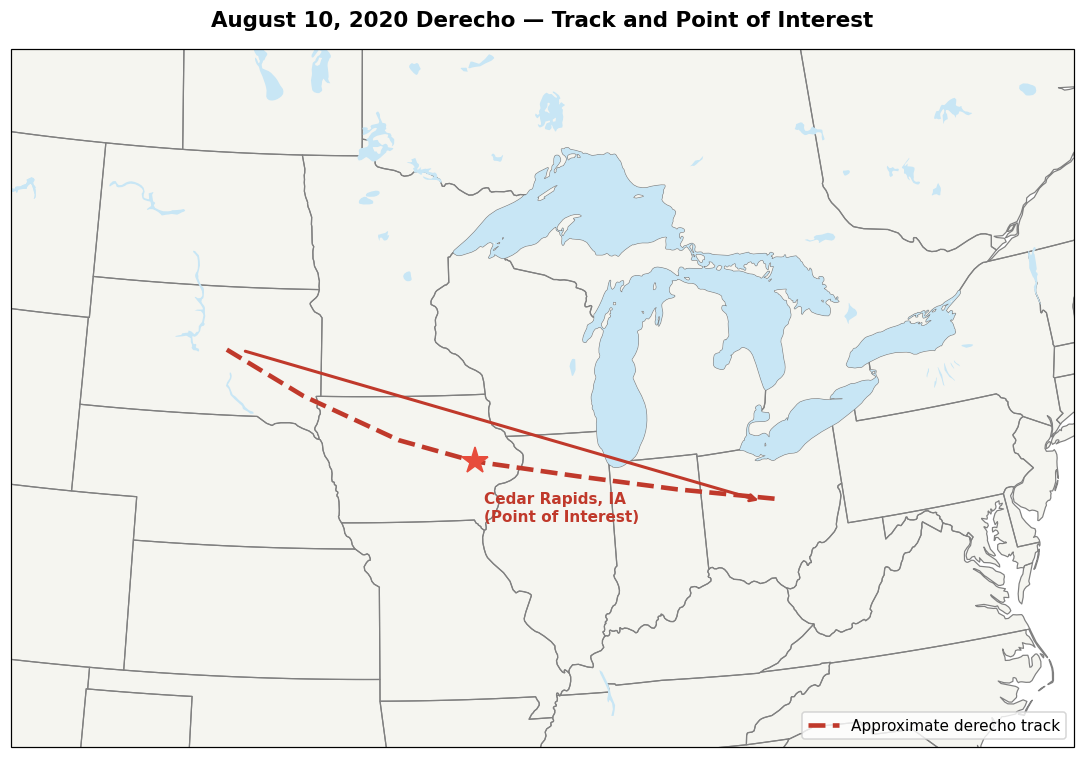

Figure 1 saved.


In [7]:
fig, ax = plt.subplots(
    figsize=(12, 7),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-95)}
)

ax.set_extent([-105, -75, 35, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='gray')
ax.add_feature(cfeature.LAND, facecolor='#f5f5f0')
ax.add_feature(cfeature.LAKES, facecolor='#c8e6f5')

# Approximate derecho track (SD → IA → IL → IN → OH)
track_lons = [-99.5, -97.0, -94.0, -91.66, -88.5, -85.5, -82.5]
track_lats = [44.5,  43.5,  42.5,   41.97,  41.5,  41.0,  40.5]

## TO DO - GET REAL DERECHO LONS/LATS TRACK POINTS TO IMPROVE ACCURACY

ax.plot(track_lons, track_lats,
        color='#c0392b', linewidth=3, linestyle='--',
        transform=ccrs.PlateCarree(), label='Approximate derecho track', zorder=5)

# Cedar Rapids marker
ax.plot(-91.66, 41.97, marker='*', markersize=18, color='#e74c3c',
        transform=ccrs.PlateCarree(), zorder=10)
ax.text(-91.45, 40.6, 'Cedar Rapids, IA\n(Point of Interest)',
        transform=ccrs.PlateCarree(), fontsize=10, fontweight='bold',
        color='#c0392b', zorder=10)

# Arrow indicating storm direction
ax.annotate('', xy=(-83, 40.5), xytext=(-99, 44.5),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2))

ax.set_title('August 10, 2020 Derecho — Track and Point of Interest',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('fig1_derecho_track.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

In [ ]:

# Select data of event in "YYY-MM-DD" format
EVENT_DATE = "2020-08-10"

# Select Site: Cedar Rapids, Iowa
SITE_NAME = "Cedar Rapids, IA"
SITE_LAT = 41.97
SITE_LON = -91.66

# Known timeline (CDT / UTC), from NWS damage surveys and SPC records.
# Cedar Rapids is UTC-5 (CDT) in August.
DERECHO_ENTERS_CR_METRO_UTC = pd.Timestamp("2020-08-10 17:30")  # ~12:30 PM CDT
OBSERVED_PEAK_GUST_MPH = 140  # NWS damage-survey estimate, SW Cedar Rapids

#Define location
points = pd.DataFrame({"latitude": [SITE_LAT], "longitude": [SITE_LON]})
points

,latitude,longitude
0,41.97,-91.66


## 3. Collect the Data

HRRR produces a fresh analysis (`fxx=0`) every hour. Looping over all 24 hours of August 10 
and extracting the 10-m wind at the grid point nearest Cedar Rapids. This gives the best hourly estimate of what actually
happened — this is the closest thing to "ground truth" available directly from the model archive.

**Note:** each `Herbie` call fetches only the small subset of GRIB2 bytes needed for the requested variables (via a `.idx` index file), not the full 1 GB file — so this loop is quick even though it spans 24 hourly files.

In [16]:

## Function for downloading HRRR data via Herbie for the locational dataframe provided

def get_hourly_analysis_wind(date_str, hour, points):
    """Fetch 10-m sustained wind (U/V) and surface gust from the HRRR
    analysis at a given UTC hour. Returns (sustained_mph, gust_mph) at the
    nearest grid point(s).

    GUST is HRRR's dedicated peak-gust diagnostic -- it accounts for
    turbulent mixing near the surface, not just the grid-mean flow, so it
    typically runs higher than sqrt(u10^2 + v10^2) and is a closer analog
    to what a damage survey or anemometer would report.
    """
    H = Herbie(
        f"{date_str} {hour:02d}:00",
        model="hrrr",
        product="sfc",
        fxx=0,
    )
    ds = H.xarray(":UGRD:10 m|:VGRD:10 m|:GUST:", remove_grib=True)
    if isinstance(ds, list):
        ds = xr.merge(ds)
    pt = ds.herbie.pick_points(points, method="nearest")

    sustained_ms = np.sqrt(pt["u10"] ** 2 + pt["v10"] ** 2)
    sustained_mph = float(sustained_ms.values.squeeze()) * 2.23694
    gust_mph = float(pt["gust"].values.squeeze()) * 2.23694
    return sustained_mph, gust_mph


records = []
for hour in range(24):
    try:
        sustained_mph, gust_mph = get_hourly_analysis_wind(EVENT_DATE, hour, points)
        records.append({"hour_utc": hour, "wind_mph": sustained_mph, "gust_mph": gust_mph})
        print(f"{hour:02d}Z  ->  sustained {sustained_mph:5.1f} mph  |  gust {gust_mph:5.1f} mph")
    except Exception as e:
        print(f"{hour:02d}Z  ->  FAILED: {e}")

analysis_df = pd.DataFrame(records)
analysis_df["valid_time"] = pd.to_datetime(EVENT_DATE) + pd.to_timedelta(
    analysis_df["hour_utc"], unit="h"
)
analysis_df.head()

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
00Z  ->  sustained   8.9 mph  |  gust  18.3 mph
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 01:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
01Z  ->  sustained   6.3 mph  |  gust  13.3 mph
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 02:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


...

/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
22Z  ->  sustained  10.2 mph  |  gust  15.6 mph
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 23:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
23Z  ->  sustained   7.9 mph  |  gust  21.8 mph


,hour_utc,wind_mph,gust_mph,valid_time
0,0,8.893370,18.296301,2020-08-10 00:00:00
1,1,6.329865,13.257685,2020-08-10 01:00:00
2,2,5.217151,13.983029,2020-08-10 02:00:00
3,3,4.553169,12.741992,2020-08-10 03:00:00
4,4,4.359739,11.832890,2020-08-10 04:00:00


## 4. Visualize the Data

In this section, we will look at:
(1) The wind speeds throughout the day at Cedar Rapids, IA
(2) A map of the wind speed at the determined "peak" of the storm
(3)

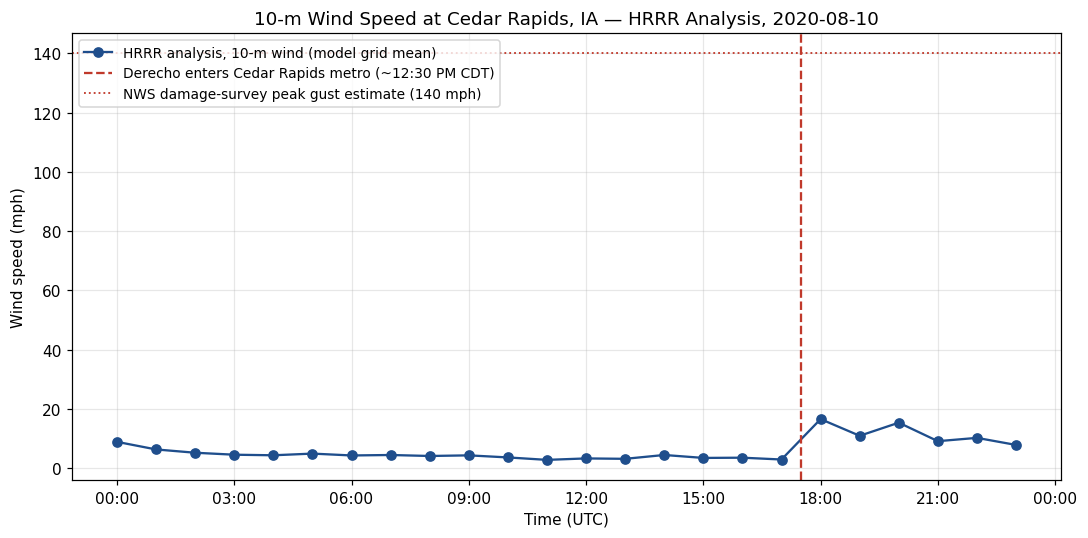

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    analysis_df["valid_time"],
    analysis_df["wind_mph"],
    marker="o",
    color="#1f4e8c",
    label="HRRR analysis, 10-m wind (model grid mean)",
)

ax.axvline(
    DERECHO_ENTERS_CR_METRO_UTC,
    color="#c0392b",
    linestyle="--",
    linewidth=1.5,
    label="Derecho enters Cedar Rapids metro (~12:30 PM CDT)",
)

ax.axhline(
    OBSERVED_PEAK_GUST_MPH,
    color="#c0392b",
    linestyle=":",
    linewidth=1.2,
    label=f"NWS damage-survey peak gust estimate ({OBSERVED_PEAK_GUST_MPH} mph)",
)

ax.set_title(f"10-m Wind Speed at {SITE_NAME} — HRRR Analysis, {EVENT_DATE}")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Wind speed (mph)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("cedar_rapids_wind_timeseries.png", dpi=150)
plt.show()


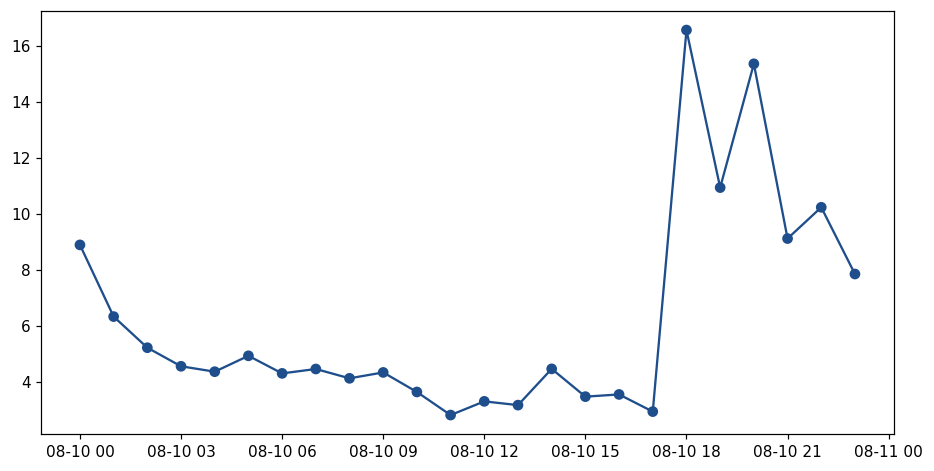

In [13]:
colors = ["#c0392b" if mph >= 58 else "#1f4e8c" for mph in analysis_df["wind_mph"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(analysis_df["valid_time"], analysis_df["wind_mph"], color="#1f4e8c", zorder=1)
ax.scatter(analysis_df["valid_time"], analysis_df["wind_mph"], c=colors, zorder=2)

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 18:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


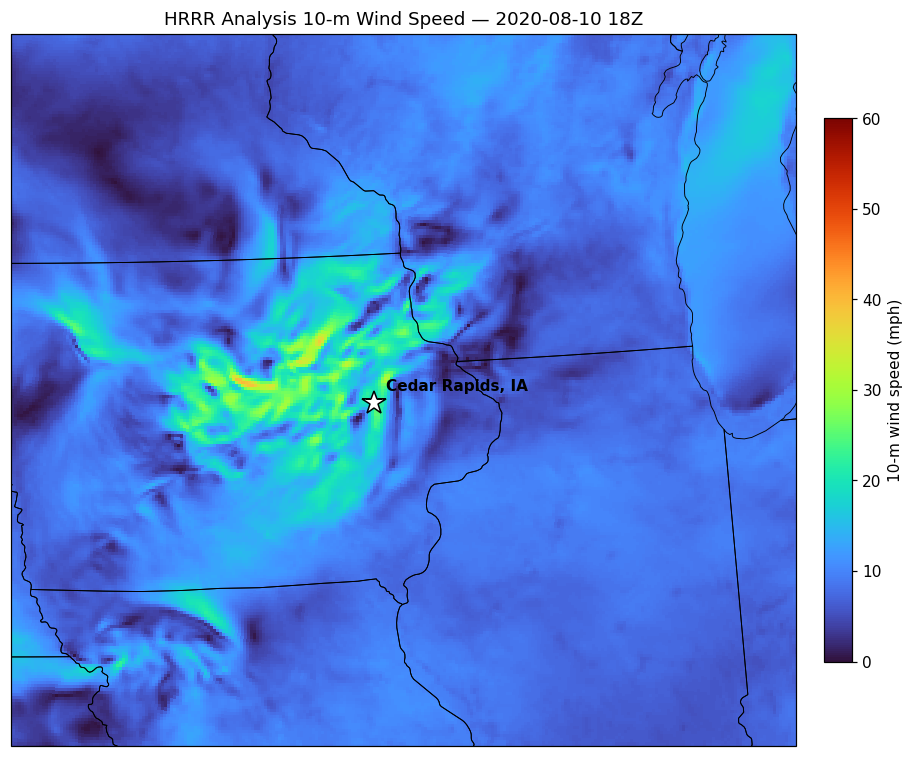

In [ ]:
#Display regional wind field map at peak hour

PEAK_HOUR_UTC = 18  # 18Z ~= 1:00 PM CDT, derecho crossing eastern Iowa

H_map = Herbie(f"{EVENT_DATE} {PEAK_HOUR_UTC:02d}:00", model="hrrr", product="sfc", fxx=0)
ds_map = H_map.xarray(":UGRD:10 m|:VGRD:10 m", remove_grib=True)
if isinstance(ds_map, list):
    ds_map = xr.merge(ds_map)

speed = np.sqrt(ds_map["u10"] ** 2 + ds_map["v10"] ** 2) * 2.23694  # mph

# Regional extent around the derecho's Iowa/Illinois track
extent = [-96, -87, 39, 45]

fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent(extent, crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(
    ds_map.longitude,
    ds_map.latitude,
    speed,
    transform=ccrs.PlateCarree(),
    cmap="turbo",
    vmin=0,
    vmax=60,
    shading="auto",
)

ax.add_feature(cfeature.STATES, linewidth=0.6, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.plot(
    SITE_LON, SITE_LAT, marker="*", color="white", markeredgecolor="black",
    markersize=16, transform=ccrs.PlateCarree(), zorder=5,
)
ax.annotate(
    SITE_NAME, (SITE_LON, SITE_LAT), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
    xytext=(8, 8), textcoords="offset points", fontsize=10, fontweight="bold",
)

cb = fig.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.75, pad=0.03)
cb.set_label("10-m wind speed (mph)")
ax.set_title(f"HRRR Analysis 10-m Wind Speed — {EVENT_DATE} {PEAK_HOUR_UTC:02d}Z")
fig.tight_layout()
fig.savefig("derecho_wind_field_map.png", dpi=150)
plt.show()
colors = ["#c0392b" if mph >= 58 else "#1f4e8c" for mph in analysis_df["wind_mph"]]

In [9]:
FORECAST_INIT_HOUR = 6  # 06Z cycle, initialized well ahead of the event
FORECAST_HOURS = range(6, 15)  # covers ~12Z-21Z valid times

fc_records = []
for fxx in FORECAST_HOURS:
    try:
        H = Herbie(
            f"{EVENT_DATE} {FORECAST_INIT_HOUR:02d}:00",
            model="hrrr",
            product="sfc",
            fxx=fxx,
        )
        ds = H.xarray(":UGRD:10 m|:VGRD:10 m", remove_grib=True)
        if isinstance(ds, list):
            ds = xr.merge(ds)
        pt = ds.herbie.pick_points(points, method="nearest")
        speed_mph = float(
            np.sqrt(pt["u10"] ** 2 + pt["v10"] ** 2).values.squeeze()
        ) * 2.23694
        valid_time = pd.Timestamp(EVENT_DATE) + pd.Timedelta(
            hours=FORECAST_INIT_HOUR
        ) + pd.Timedelta(hours=fxx)
        fc_records.append({"fxx": fxx, "valid_time": valid_time, "wind_mph": speed_mph})
        print(f"f{fxx:02d} (valid {valid_time:%H:%M}Z) -> {speed_mph:5.1f} mph")
    except Exception as e:
        print(f"f{fxx:02d} -> FAILED: {e}")

forecast_df = pd.DataFrame(fc_records)
forecast_df.head()

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 06:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ aws


/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


f06 (valid 12:00Z) ->   1.2 mph
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 06:00 UTC F07 ┊ GRIB2 @ aws ┊ IDX @ aws


/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


f07 (valid 13:00Z) ->   6.8 mph
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 06:00 UTC F08 ┊ GRIB2 @ aws ┊ IDX @ aws


...

/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


f13 (valid 19:00Z) ->  11.1 mph
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 06:00 UTC F14 ┊ GRIB2 @ aws ┊ IDX @ aws


/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/srw-analysis/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


f14 (valid 20:00Z) ->   2.7 mph


,fxx,valid_time,wind_mph
0,6,2020-08-10 12:00:00,1.174608
1,7,2020-08-10 13:00:00,6.836670
2,8,2020-08-10 14:00:00,5.883834
3,9,2020-08-10 15:00:00,3.776454
4,10,2020-08-10 16:00:00,4.730260


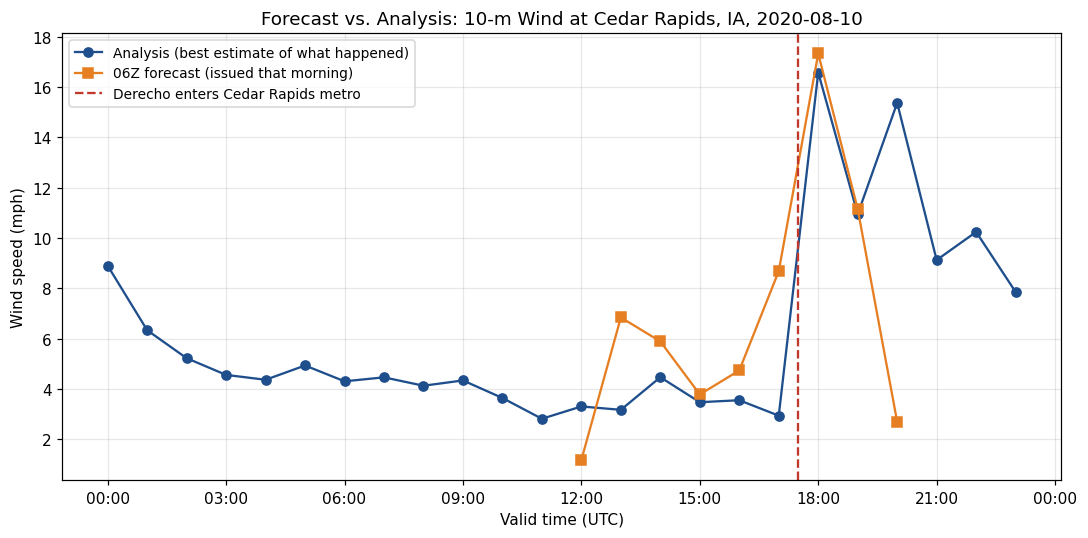

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    analysis_df["valid_time"], analysis_df["wind_mph"],
    marker="o", color="#1f4e8c", label="Analysis (best estimate of what happened)",
)
ax.plot(
    forecast_df["valid_time"], forecast_df["wind_mph"],
    marker="s", color="#e67e22",
    label=f"{FORECAST_INIT_HOUR:02d}Z forecast (issued that morning)",
)

ax.axvline(
    DERECHO_ENTERS_CR_METRO_UTC, color="#c0392b", linestyle="--",
    linewidth=1.5, label="Derecho enters Cedar Rapids metro",
)

ax.set_title(f"Forecast vs. Analysis: 10-m Wind at {SITE_NAME}, {EVENT_DATE}")
ax.set_xlabel("Valid time (UTC)")
ax.set_ylabel("Wind speed (mph)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("forecast_vs_analysis.png", dpi=150)
plt.show()


In [ ]:
# Match each forecast valid time to the analysis value for that same hour,
# then classify the forecast as under-, over-, or correctly-predicting wind speed.

comparison = pd.merge(
    forecast_df,
    analysis_df[["valid_time", "wind_mph"]],
    on="valid_time",
    suffixes=("_forecast", "_analysis"),
)

# Floats are almost never *exactly* equal, so "Correct" is defined as
# "within 1 mph" rather than requiring bit-for-bit equality.
TOLERANCE_MPH = 1.0 

for _, row in comparison.iterrows():
    forecast_mph = row["wind_mph_forecast"]
    analysis_mph = row["wind_mph_analysis"]
    diff = forecast_mph - analysis_mph

    if diff < -TOLERANCE_MPH:
        verdict = "Under-forecast"
    elif diff > TOLERANCE_MPH:
        verdict = "Over-forecast"
    else:
        verdict = "Correct"

    print(
        f"{row['valid_time']:%H:%M} UTC  ->  "
        f"forecast {forecast_mph:5.1f} mph vs analysis {analysis_mph:5.1f} mph  "
        f"({verdict}, diff {diff:+.1f} mph)"
    )


12:00 UTC  ->  forecast   1.2 mph vs analysis   3.3 mph  (Under-forecast, diff -2.1 mph)
13:00 UTC  ->  forecast   6.8 mph vs analysis   3.2 mph  (Over-forecast, diff +3.7 mph)
14:00 UTC  ->  forecast   5.9 mph vs analysis   4.5 mph  (Over-forecast, diff +1.4 mph)
15:00 UTC  ->  forecast   3.8 mph vs analysis   3.5 mph  (Correct, diff +0.3 mph)
16:00 UTC  ->  forecast   4.7 mph vs analysis   3.5 mph  (Over-forecast, diff +1.2 mph)
17:00 UTC  ->  forecast   8.7 mph vs analysis   2.9 mph  (Over-forecast, diff +5.7 mph)
18:00 UTC  ->  forecast  17.3 mph vs analysis  16.6 mph  (Correct, diff +0.8 mph)
19:00 UTC  ->  forecast  11.1 mph vs analysis  10.9 mph  (Correct, diff +0.2 mph)
20:00 UTC  ->  forecast   2.7 mph vs analysis  15.4 mph  (Under-forecast, diff -12.7 mph)


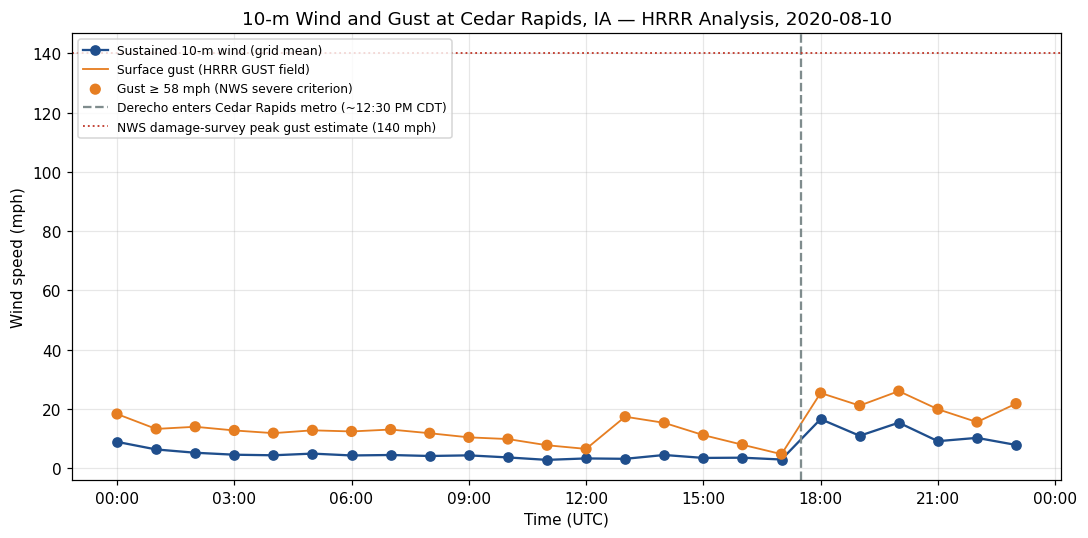

In [17]:
SEVERE_GUST_THRESHOLD_MPH = 58  # NWS criterion for a "severe" wind report

# Simple if/else, applied per-hour: flag which points crossed the
# severe-wind threshold so they can be colored differently on the plot.
point_colors = []
for mph in analysis_df["gust_mph"]:
    if mph >= SEVERE_GUST_THRESHOLD_MPH:
        point_colors.append("#c0392b")  # red: severe
    else:
        point_colors.append("#e67e22")  # orange: sub-severe gust

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    analysis_df["valid_time"], analysis_df["wind_mph"],
    marker="o", color="#1f4e8c", label="Sustained 10-m wind (grid mean)",
)
ax.plot(
    analysis_df["valid_time"], analysis_df["gust_mph"],
    color="#e67e22", linewidth=1.2, zorder=1, label="Surface gust (HRRR GUST field)",
)
ax.scatter(
    analysis_df["valid_time"], analysis_df["gust_mph"],
    c=point_colors, zorder=2, s=40,
    label=f"Gust ≥ {SEVERE_GUST_THRESHOLD_MPH} mph (NWS severe criterion)",
)

ax.axvline(
    DERECHO_ENTERS_CR_METRO_UTC,
    color="#7f8c8d",
    linestyle="--",
    linewidth=1.5,
    label="Derecho enters Cedar Rapids metro (~12:30 PM CDT)",
)

ax.axhline(
    OBSERVED_PEAK_GUST_MPH,
    color="#c0392b",
    linestyle=":",
    linewidth=1.2,
    label=f"NWS damage-survey peak gust estimate ({OBSERVED_PEAK_GUST_MPH} mph)",
)

ax.set_title(f"10-m Wind and Gust at {SITE_NAME} — HRRR Analysis, {EVENT_DATE}")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Wind speed (mph)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("cedar_rapids_wind_timeseries.png", dpi=150)
plt.show()

In [11]:
REFC_HOURS = range(12, 23)  # 12Z-22Z: covers pre-storm through the IL/IN stage

refc_frames = []
for hour in REFC_HOURS:
    try:
        H = Herbie(f"{EVENT_DATE} {hour:02d}:00", model="hrrr", product="sfc", fxx=0)
        ds = H.xarray(":REFC:", remove_grib=True)
        if isinstance(ds, list):
            ds = xr.merge(ds)
        refc_frames.append({"hour": hour, "ds": ds})
        print(f"{hour:02d}Z reflectivity pulled")
    except Exception as e:
        print(f"{hour:02d}Z FAILED: {e}")


✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 12:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
12Z reflectivity pulled
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 13:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
13Z reflectivity pulled
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 14:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
14Z reflectivity pulled
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 15:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
15Z reflectivity pulled
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 16:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
16Z reflectivity pulled
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 17:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
17Z reflectivity pulled
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 18:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
18Z reflectivity pulled
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 19:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
19Z reflectivity pulled
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2020-Aug-10 20:00 UTC F00 ┊ GRIB2 @ aws ┊ I

## Summary

This notebook is intended to show what analysis and visualization is possible by using operational forecasts without High Performance Computing (HPC) access and resources. 

## Acknowledgments

- **NOAA EPIC** for the SRW tutorial, pre-staged data, and HPC allocation on Hercules
- **Dr. Lilly Jones**, GEOG 5663 Capstone Instructor
- Tutorial: [UFS SRW App — August 10, 2020 Derecho](https://www.ufs.epic.noaa.gov/srw-tutorial-august102020-derecho/)
- Reference: Gallus Jr. and Harrold (2023), *Weather and Forecasting*